Using Device: cpu


100%|██████████| 170M/170M [38:45<00:00, 73.3kB/s]


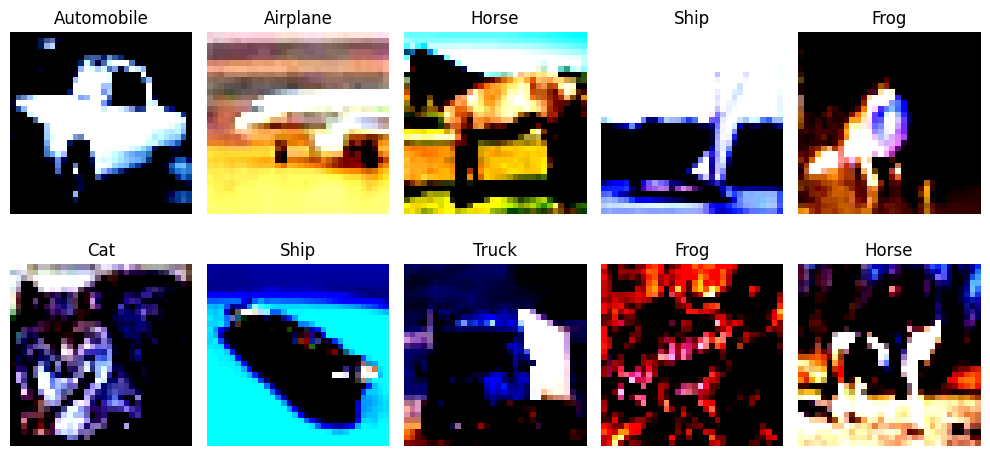

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)
Epoch [1/10] Loss: 1.2213
Epoch [2/10] Loss: 0.8346
Epoch [3/10] Loss: 0.6334
Epoch [4/10] Loss: 0.4567
Epoch [5/10] Loss: 0.2928
Epoch [6/10] Loss: 0.1772
Epoch [7/10] Loss: 0.1104
Epoch [8/10] Loss: 0.0909
Epoch [9/10] Loss: 0.0794
Epoch [10/10] Loss: 0.0672


Test Accuracy: 73.06%
Model saved successfully.


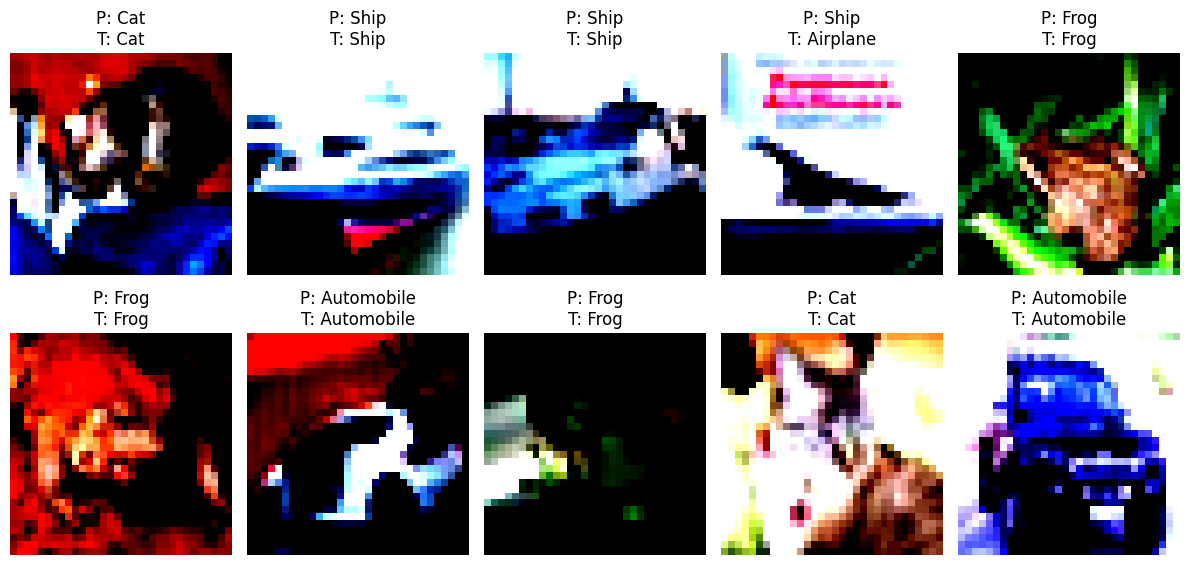

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device:", device)

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Training Dataset
train_dataset = CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Testing Dataset
test_dataset = CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Class Names
classes = (
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)

print(model)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

    model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "cifar10_cnn.pth")

print("Model saved successfully.")

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)

    plt.title(f"P: {classes[predicted[i]]}\nT: {classes[labels[i]]}")

    plt.axis("off")

plt.tight_layout()

plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')